# Tutorial 05 – Run Coupled PywrDRB

This tutorial walks you through how to run the coupled Pywr-DRB model to generate two outputs:
1.	Maximum daily water temperature at Lordville, and
2.	Salt front location in the estuary.

The coupling relies on two LSTM models—TempLSTM and SalinityLSTM—provided in the plug-in PywrDRB-ML.
Before starting, please make sure you have downloaded this plug-in, [PywrDRB-ML](https://github.com/cylin928/PywrDRB-ML). => need to update the link

This tutorial demonstrates how to run the coupled model in three different ways:
- Synchronous (tight coupling): step-wise information exchange between models.
- Asynchronous (loose coupling): sequential execution of each model.
- Hybrid coupling: an advanced strategy combining both approaches, illustrated with a rule-based thermal control example.

## 

# Setup PywrDRB-ML plug-in path

In [34]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import pywrdrb

# Setup PywrDRB-ML plug-in path
ml_path = "/Users/CL/Documents/GitHub/PywrDRB-ML"
# Set inflow type
inflow_type = 'pub_nhmv10_BC_withObsScaled'
# Set output folder
output_folder = os.path.join(ml_path, "outputs", "Tutorial_05_Coupled_PywrDRB")
# Create output directory if it does not exist
os.makedirs(output_folder, exist_ok=True)

# Set LSTM model path
templstm1_path = os.path.join(ml_path, "models", "TempLSTM", "TempLSTM1.yml")
templstm2_path = os.path.join(ml_path, "models", "TempLSTM", "TempLSTM2.yml")
tavg2tmax_coefs_path = os.path.join(ml_path, "models", "TempLSTM", "Tavg2Tmax_coefs.json")
salinitylstm1_path = os.path.join(ml_path, "models", "SalinityLSTM", "SalinityLSTM.yml")

# Synchronous Coupling for Water Temperature and Salt Front Simulation

The following code will walk you through how to build a coupled model in a **synchronous coupling mode** using the model builder.

This is achieved by providing additional settings through the `options` argument in the model builder, for example:

```python
options = {
    "temperature_model": temp_options,
    "salinity_model": salinity_options,
}

## "temperature_model" setting

The `temperature_model` is an dictionary with the following keys.

| key                                      | type        | typical value                   | purpose                            |
|------------------------------------------|-------------|---------------------------------|------------------------------------|
| ml_model_type                            | str         | "lstm"                          | "lstm" is the only support model type|
| PywrDRB_ML_plugin_path                   | path        | ml_path                         | plugin path                        |
| model1                                   | path        | templstm1_path                  | TempLSTM1 model file               |
| model2                                   | path        | templstm2_path                  | TempLSTM2 model file               |
| Tavg2Tmax_coefs                          | path/dict   | tavg2tmax_coefs_path            | convert Tavg→Tmax                  |
| start_date                               | str         | "1979-01-01"                    | lstm simulation start (can be any date within the pywrdrb simulation period)              |
| end_date                                 | str         | "2023-12-31"                    | lstm simulation end (can be any date within the pywrdrb simulation period)               |
| activate_thermal_control                 | bool        | False                           | true if thermal control policy is given|
| Q_C_lstm_var_name                        | str         | "QbcTavg_Q_C"                   | name of Q_C input var in LSTM      |
| Q_i_lstm_var_name                        | str         | "QbcTavg_Q_i"                   | name of inflow input var in LSTM   |
| cannonsville_storage_pct_lstm_var_name   | str         | "bc_cannonsville_storage_pct"   | storage input var in LSTM          |
| thermal_mitigation_bank_size             | numeric     | 1620                            | annual thermal bank size (mgd)     |
| asycronized_update                       | bool        | False                           | if true, then do asynchronous updates|
| debug                                    | bool        | True                           | if true, store additional intermediate variables|


In [35]:
temp_options = {
    "ml_model_type": "lstm",    # Do not change this value
    "PywrDRB_ML_plugin_path": ml_path,
    "model1": templstm1_path,
    "model2": templstm2_path,
    "Tavg2Tmax_coefs": tavg2tmax_coefs_path,
    "start_date": "1979-01-01",
    "end_date": "2023-12-31",
    "activate_thermal_control": False,
    "Q_C_lstm_var_name": "QbcTavg_Q_C", # Change only if you retain the LSTM model with different feature names.
    "Q_i_lstm_var_name": "QbcTavg_Q_i", # Change only if you retain the LSTM model with different feature names.
    "cannonsville_storage_pct_lstm_var_name": "bc_cannonsville_storage_pct", # Change only if you retain the LSTM model with different feature names.
    "thermal_mitigation_bank_size": 1620,  # mgd
    "asycronized_update": False,
    "debug": True
    }

## "salinity_model" settings

Similar to `temp_model` settings, `salinity_model` is a dictionary with the following keys.

| key                          | type    | typical value         | purpose                         |
|-------------------------------|---------|------------------------|---------------------------------|
| ml_model_type                 | str     | "lstm"                 | "lstm" is the only support model type                 |
| PywrDRB_ML_plugin_path        | path    | ml_path                | plugin path               |
| model_salinity                | path    | salinitylstm1_path     | SalinityLSTM model file              |
| start_date                    | str     | "1979-01-01"           | lstm simulation start (can be any date within the pywrdrb simulation period)|
| end_date                      | str     | "2023-12-31"           | lstm simulation start (can be any date within the pywrdrb simulation period)|
| Q_Trenton_lstm_var_name       | str     | "Q_Trenton_bc"         | name of Trenton flow input var in LSTM  |
| Q_Schuylkill_lstm_var_name    | str     | "Q_Schuylkill_bc"      | name of Schuylkill flow input var in LSTM|
| asycronized_update            | bool    | False                  | if true, then do asynchronous updates |
| debug                         | bool    | True                  | if true, store additional intermediate variables |

In [36]:
salinity_options = {
    "ml_model_type": "lstm",
    "PywrDRB_ML_plugin_path": ml_path,
    "model_salinity": salinitylstm1_path,
    "start_date": "1979-01-01",
    "end_date": "2023-12-31",
    "Q_Trenton_lstm_var_name": "Q_Trenton_bc",
    "Q_Schuylkill_lstm_var_name": "Q_Schuylkill_bc",
    "asycronized_update": False,
    "debug": True
    }

## Build coupled model with synchronous coupling strategy

Here, we follow the previous tutorials that use the model builder to create a model, but with additional options — `temperature_model` and `salinity_model` — provided.

In [37]:
#%% Create coupled Pywr-DRB model with synchronous coupling strategy

# Set model and output filenames
model_filename = os.path.join(output_folder, f"synchronous_{inflow_type}.json")

# Define temperature and salinity model options
mb = pywrdrb.ModelBuilder(
    inflow_type=inflow_type,
    start_date="1978-01-01",
    end_date="2023-12-31",
    options={
        "temperature_model": temp_options,
        "salinity_model": salinity_options,
        }
    )

mb.make_model()
mb.write_model(model_filename)

Run the model.

In [38]:
#%% Load the model and run it
output_filename = os.path.join(output_folder, f"synchronous_{inflow_type}.hdf5")

# Load model (timed)
model = pywrdrb.Model.load(str(model_filename))

# Initialize recorder (timed)
recorder = pywrdrb.OutputRecorder(
    model=model,
    output_filename=output_filename,
    parameters=[p for p in model.parameters if p.name],
)

# Run model (timed)
t_start = time.perf_counter()
stats = model.run()
t_end = time.perf_counter()
print(f"Model run time: {t_end - t_start:.2f} s")

/var/folders/xb/hb6grp9d09s21b7zwbpt8yhw0000gn/T/ipykernel_84810/4136861246.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stats = model.run()


Model run time: 33.21 s


Load outputs and print out water temperature and salt front location simulation results.

In [39]:
# Load outputs and print out water temperature and salt front location simulation results
data = pywrdrb.Data()
results_sets = [
    'temperature',
    'salinity',
    ]
data.load_output(output_filenames=[output_filename], results_sets=results_sets)

df_temperature = data.temperature[f"synchronous_{inflow_type}"][0]
df_salinity = data.salinity[f"synchronous_{inflow_type}"][0]

print("Water Temperature Simulation Results:")
print(df_temperature["1979":].head())

print("Salinity Simulation Results:")
print(df_salinity["1979":].head())

Water Temperature Simulation Results:
            thermal_release_requirement  temperature_after_thermal_release_mu  \
1979-01-01                          0.0                              3.032281   
1979-01-02                          0.0                              3.199900   
1979-01-03                          0.0                              0.742043   
1979-01-04                          0.0                              0.578121   
1979-01-05                          0.0                              0.662111   

            forecasted_temperature_before_thermal_release_mu  
1979-01-01                                               NaN  
1979-01-02                                               NaN  
1979-01-03                                               NaN  
1979-01-04                                               NaN  
1979-01-05                                               NaN  
Salinity Simulation Results:
            salt_front_location_mu
1979-01-01               79.64107

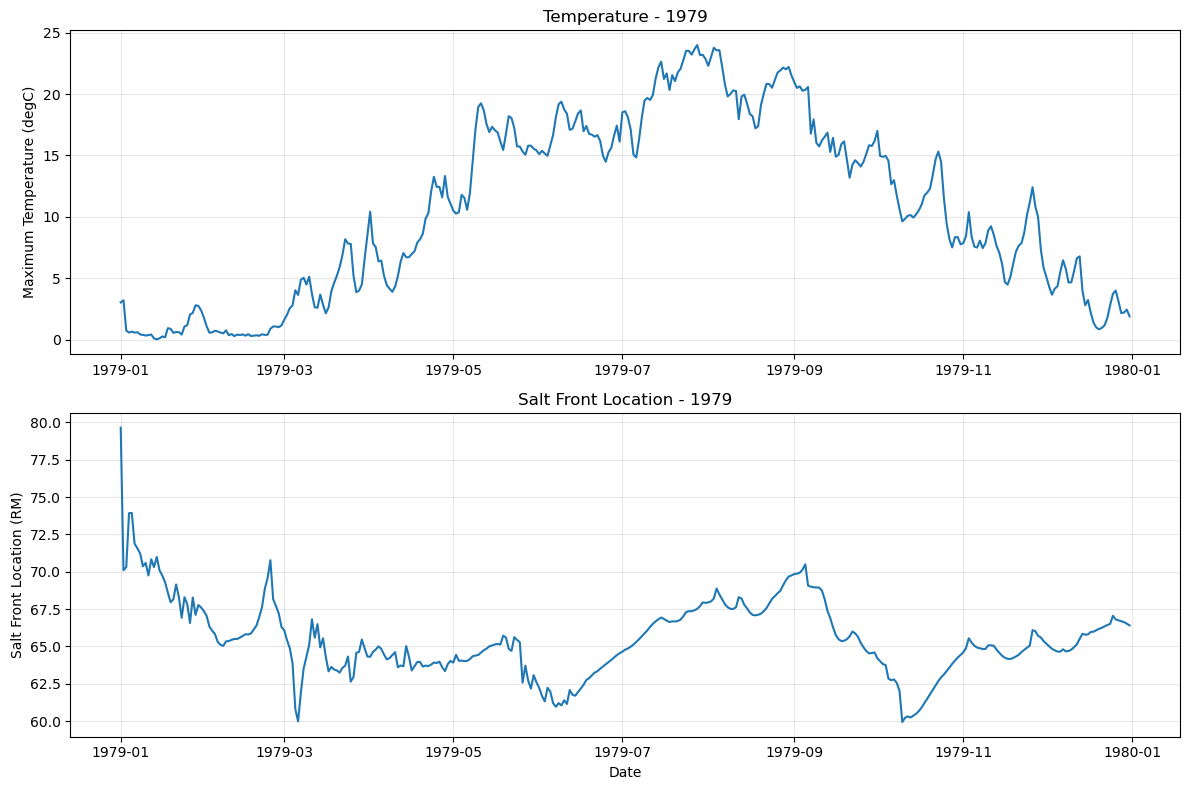

In [40]:
# Filter data for 1979
start_date = '1979-01-01'
end_date = '1979-12-31'

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot temperature_after_thermal_release_mu
ax1.plot(df_temperature.loc[start_date:end_date].index, 
         df_temperature.loc[start_date:end_date]['temperature_after_thermal_release_mu'])
ax1.set_ylabel('Maximum Temperature (degC)')
ax1.set_title('Temperature - 1979')
ax1.grid(True, alpha=0.3)

# Plot salt_front_location_mu
ax2.plot(df_salinity.loc[start_date:end_date].index, 
         df_salinity.loc[start_date:end_date]['salt_front_location_mu'])
ax2.set_ylabel('Salt Front Location (RM)')
ax2.set_xlabel('Date')
ax2.set_title('Salt Front Location - 1979')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Asynchronous Coupling for Water Temperature and Salt Front Simulation

Asynchronous coupling runs the Pywr-DRB simulation first, then runs the TempLSTM and SalinityLSTM models to simulate water temperature and the salt-front location. The primary advantage is that it can take advantage of vectorized computation inside the LSTM models, which can potentially reduce runtime depending on your machain. However, this approach is a one-way coupling: feedback from the LSTM results back into the Pywr-DRB simulation is not possible. For example, flow targets at Montague and Trenton cannot be adjusted dynamically based on the salt-front location during a drought emergency.

To enable asynchronous coupling, set `asycronized_update` to True.
Then, exercute the LSTM simulation after pywrdrb simulation. Please see the demostration below.

In [41]:
#%% Create coupled Pywr-DRB model with synchronous coupling strategy

# Set model and output filenames
model_filename = os.path.join(output_folder, f"asynchronous_{inflow_type}.json")

# Define temperature and salinity model options
mb = pywrdrb.ModelBuilder(
    inflow_type=inflow_type,
    start_date="1978-01-01",
    end_date="2023-12-31",
    options={
        "temperature_model": temp_options,
        "salinity_model": salinity_options,
        }
    )

mb.make_model()
mb.write_model(model_filename)

temp_options = {
    "ml_model_type": "lstm",    # Do not change this value
    "PywrDRB_ML_plugin_path": ml_path,
    "model1": templstm1_path,
    "model2": templstm2_path,
    "Tavg2Tmax_coefs": tavg2tmax_coefs_path,
    "start_date": "1979-01-01",
    "end_date": "2023-12-31",
    "activate_thermal_control": False,
    "Q_C_lstm_var_name": "QbcTavg_Q_C", # Change only if you retain the LSTM model with different feature names.
    "Q_i_lstm_var_name": "QbcTavg_Q_i", # Change only if you retain the LSTM model with different feature names.
    "cannonsville_storage_pct_lstm_var_name": "bc_cannonsville_storage_pct", # Change only if you retain the LSTM model with different feature names.
    "thermal_mitigation_bank_size": 1620,  # mgd
    "asycronized_update": True,
    "debug": True
    }

salinity_options = {
    "ml_model_type": "lstm",
    "PywrDRB_ML_plugin_path": ml_path,
    "model_salinity": salinitylstm1_path,
    "start_date": "1979-01-01",
    "end_date": "2023-12-31",
    "Q_Trenton_lstm_var_name": "Q_Trenton_bc",
    "Q_Schuylkill_lstm_var_name": "Q_Schuylkill_bc",
    "asycronized_update": True,
    "debug": True
    }

#%% Load the model and run it
output_filename = os.path.join(output_folder, f"asynchronous_{inflow_type}.hdf5")

# Load model (timed)
model = pywrdrb.Model.load(str(model_filename))

# Initialize recorder (timed)
recorder = pywrdrb.OutputRecorder(
    model=model,
    output_filename=output_filename,
    parameters=[p for p in model.parameters if p.name],
)

# Run model (timed)
t_start = time.perf_counter()

stats = model.run()

# Run TempLSTM model asynchronously
ml_model = model.parameters["temperature_model"].ml_model
ml_model.update_until(date="2024-01-01")
df_temperature = pd.DataFrame(ml_model.records, index=ml_model.dates)

# Run SalinityLSTM model asynchronously
ml_model = model.parameters["salinity_model"].ml_model
ml_model.update_until(date="2024-01-01")
df_salinity = pd.DataFrame(ml_model.records, index=ml_model.dates)

t_end = time.perf_counter()
print(f"Model run time: {t_end - t_start:.2f} s")

/var/folders/xb/hb6grp9d09s21b7zwbpt8yhw0000gn/T/ipykernel_84810/3572225231.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stats = model.run()


Model run time: 34.08 s


In [42]:
# Print out water temperature and salt front location simulation results
print("Water Temperature Simulation Results:")
print(df_temperature["1979":].head())

print("Salinity Simulation Results:")
print(df_salinity["1979":].head())


Water Temperature Simulation Results:
                   Q_C         Q_i  cannonsville_storage_pct    T_C_mu  \
1979-01-01   38.778947   268.34823                 61.501925  3.276994   
1979-01-02   38.778947  2487.51793                 69.643988  3.195807   
1979-01-03   38.778947  4570.04333                 75.425780  2.295275   
1979-01-04  260.044447  3116.63133                 77.279056  2.115626   
1979-01-05  228.397647  1757.24843                 78.193572  2.353731   

              T_C_sd    T_i_mu     T_i_sd  Tavg_L_mu  Tavg_L_sd    T_L_mu  \
1979-01-01  0.605183  2.374315  13.868979   2.488290  12.118075  3.032281   
1979-01-02  0.675637  2.639728   1.222938   2.648263   1.204210  3.199900   
1979-01-03  0.647408  0.285615   0.559464   0.302525   0.554783  0.742043   
1979-01-04  0.657547 -0.018254   0.293720   0.146080   0.275789  0.578121   
1979-01-05  0.611838 -0.050282   0.239419   0.226238   0.223262  0.662111   

               T_L_sd  thermal_releases  remained_bank

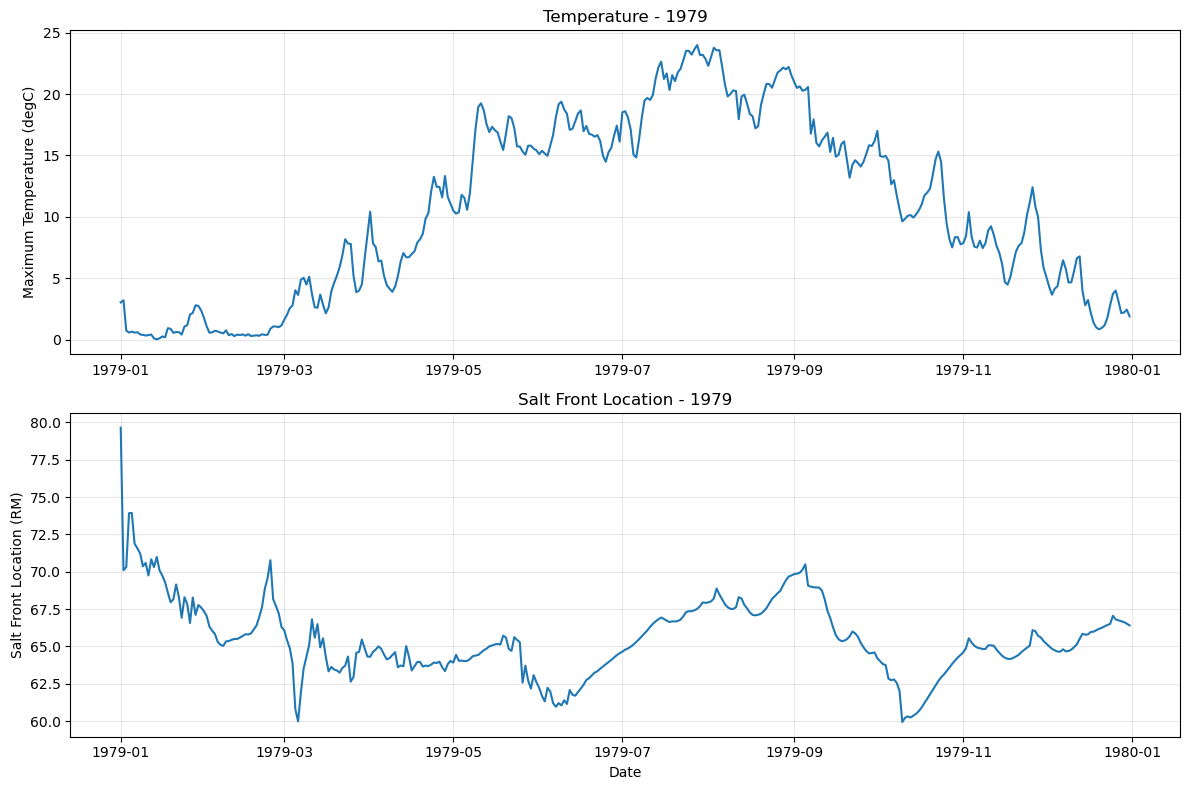

In [44]:
# Filter data for 1979
start_date = '1979-01-01'
end_date = '1979-12-31'

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot temperature_after_thermal_release_mu
ax1.plot(df_temperature.loc[start_date:end_date].index, 
         df_temperature.loc[start_date:end_date]['T_L_mu'])
ax1.set_ylabel('Maximum Temperature (degC)')
ax1.set_title('Temperature - 1979')
ax1.grid(True, alpha=0.3)

# Plot salt_front_location_mu
ax2.plot(df_salinity.loc[start_date:end_date].index, 
         df_salinity.loc[start_date:end_date]['sf_mu'])
ax2.set_ylabel('Salt Front Location (RM)')
ax2.set_xlabel('Date')
ax2.set_title('Salt Front Location - 1979')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

dict_keys(['aynchronous_pub_nhmv10_BC_withObsScaled'])